# 🚀 Final Summary & Results

## Aerial Object Classification & Detection

This notebook presents:
- Final model comparison
- Selected best model
- Evaluation results
- Detection outputs (YOLOv8)
- Key insights & conclusions

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

In [3]:
PROJECT_ROOT = Path("/content/drive/MyDrive/Aerial_Object_Classification_Detection")

reports_dir = PROJECT_ROOT / "reports"
figures_eval_dir = PROJECT_ROOT / "figures" / "evaluation"
models_dir = PROJECT_ROOT / "models"
docs_images_dir = PROJECT_ROOT / "docs" / "images"

comparison_csv_path = reports_dir / "model_comparison.csv"
evaluation_report_path = reports_dir / "evaluation_report.md"

final_model_path = models_dir / "classification" / "final" / "best_classifier.keras"
final_metrics_path = models_dir / "classification" / "final" / "final_metrics.json"

In [4]:
comparison_df = pd.read_csv(comparison_csv_path)
comparison_df

,model_name,backbone,model_path,metrics_path,accuracy,precision,recall,f1_score,val_accuracy,generalization_gap_abs,...,deployment_note,confusion_matrix,classification_report,class_names,confusion_matrix_path,curves_paths,y_pred,y_score,streamlit_suitability,selection_score
0,resnet50,resnet50,/content/drive/MyDrive/Aerial_Object_Classific...,/content/drive/MyDrive/Aerial_Object_Classific...,0.986047,1.000000,0.968085,0.983784,0.966063,0.019983,...,Heavier backbone; good accuracy potential but ...,"[[121, 0], [3, 91]]","{'bird': {'precision': 0.9758064516129032, 're...","['bird', 'drone']",/content/drive/MyDrive/Aerial_Object_Classific...,['/content/drive/MyDrive/Aerial_Object_Classif...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,[5.53898863e-04 1.52375986e-04 1.59024828e-04 ...,limited,0.984835
1,efficientnetb0,efficientnetb0,/content/drive/MyDrive/Aerial_Object_Classific...,/content/drive/MyDrive/Aerial_Object_Classific...,0.972093,0.978261,0.957447,0.967742,0.986425,0.014332,...,Good balance between efficiency and accuracy.,"[[119, 2], [4, 90]]","{'bird': {'precision': 0.967479674796748, 'rec...","['bird', 'drone']",/content/drive/MyDrive/Aerial_Object_Classific...,['/content/drive/MyDrive/Aerial_Object_Classif...,[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,[9.98186052e-01 5.49703618e-05 5.18007837e-05 ...,good,0.971171
2,custom_cnn,custom_cnn,/content/drive/MyDrive/Aerial_Object_Classific...,/content/drive/MyDrive/Aerial_Object_Classific...,0.827907,0.827586,0.765957,0.795580,0.780543,0.047364,...,Light-to-moderate size custom model; suitable ...,"[[106, 15], [22, 72]]","{'bird': {'precision': 0.828125, 'recall': 0.8...","['bird', 'drone']",/content/drive/MyDrive/Aerial_Object_Classific...,['/content/drive/MyDrive/Aerial_Object_Classif...,[0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0...,[9.76640135e-02 9.14474111e-03 1.13636325e-03 ...,good,0.821206


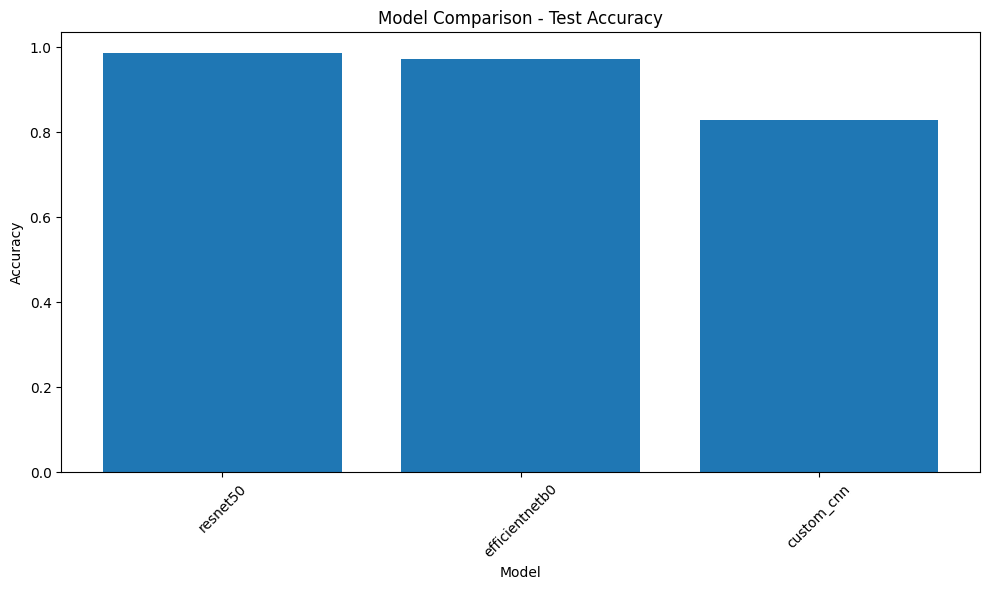

In [5]:
plt.figure(figsize=(10, 6))
plt.bar(comparison_df["model_name"], comparison_df["accuracy"])
plt.title("Model Comparison - Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 🏆 Best Model Selection

The best model is selected based on:
- Highest test accuracy
- Balanced precision/recall
- Generalization gap
- Deployment suitability

In [7]:
best_model_row = comparison_df.sort_values(by="accuracy", ascending=False).iloc[0]

print("Best Model:", best_model_row["model_name"])
print("Accuracy:", best_model_row["accuracy"])
print("Precision:", best_model_row["precision"])
print("Recall:", best_model_row["recall"])
print("F1 Score:", best_model_row["f1_score"])

Best Model: resnet50
Accuracy: 0.986046511627907
Precision: 1.0
Recall: 0.9680851063829788
F1 Score: 0.9837837837837838


In [8]:
with open(final_metrics_path, "r") as f:
    final_metrics = json.load(f)

print(json.dumps(final_metrics, indent=2)[:1500])

{
  "selected_model_name": "resnet50",
  "selected_model_path": "/content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/resnet50/best_model.keras",
  "exported_final_model_path": "/content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/final/best_classifier.keras",
  "class_mapping_path": "/content/drive/MyDrive/Aerial_Object_Classification_Detection/models/classification/final/class_mapping.json",
  "selected_model_metrics": {
    "accuracy": 0.986046511627907,
    "precision": 1.0,
    "recall": 0.9680851063829787,
    "f1_score": 0.9837837837837838,
    "val_accuracy": 0.9660633484162896,
    "generalization_gap_abs": 0.019983163211617416,
    "training_time_seconds": 8201.833737824,
    "model_size_mb": 96.633,
    "speed_bucket": "slower",
    "deployment_note": "Heavier backbone; good accuracy potential but slower deployment.",
    "streamlit_suitability": "limited"
  },
  "all_model_comparisons": [
    {
      "model_name"

## 📊 Confusion Matrix

The confusion matrix shows classification performance across classes.

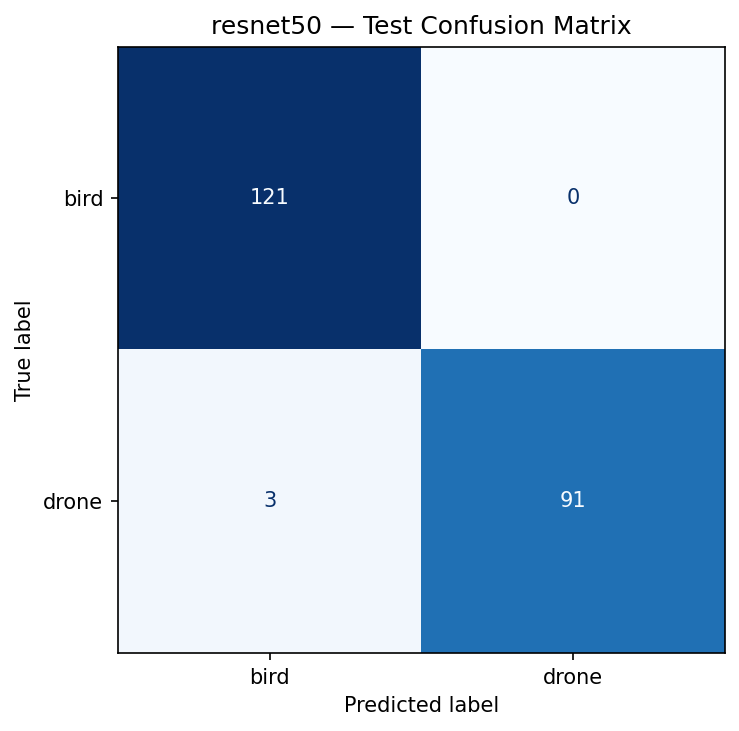

In [9]:
confusion_matrix_path = docs_images_dir / "confusion_matrix.png"

display(Image(filename=str(confusion_matrix_path)))

## 📈 Training Curves (Custom CNN)

These plots show:
- Accuracy progression
- Loss reduction

In [10]:
accuracy_curve = docs_images_dir / "accuracy_curve.png"
loss_curve = docs_images_dir / "loss_curve.png"

if accuracy_curve.exists():
    display(Image(filename=str(accuracy_curve)))

if loss_curve.exists():
    display(Image(filename=str(loss_curve)))

## 🎯 YOLOv8 Detection Results

Below are sample predictions from the trained YOLOv8 model.

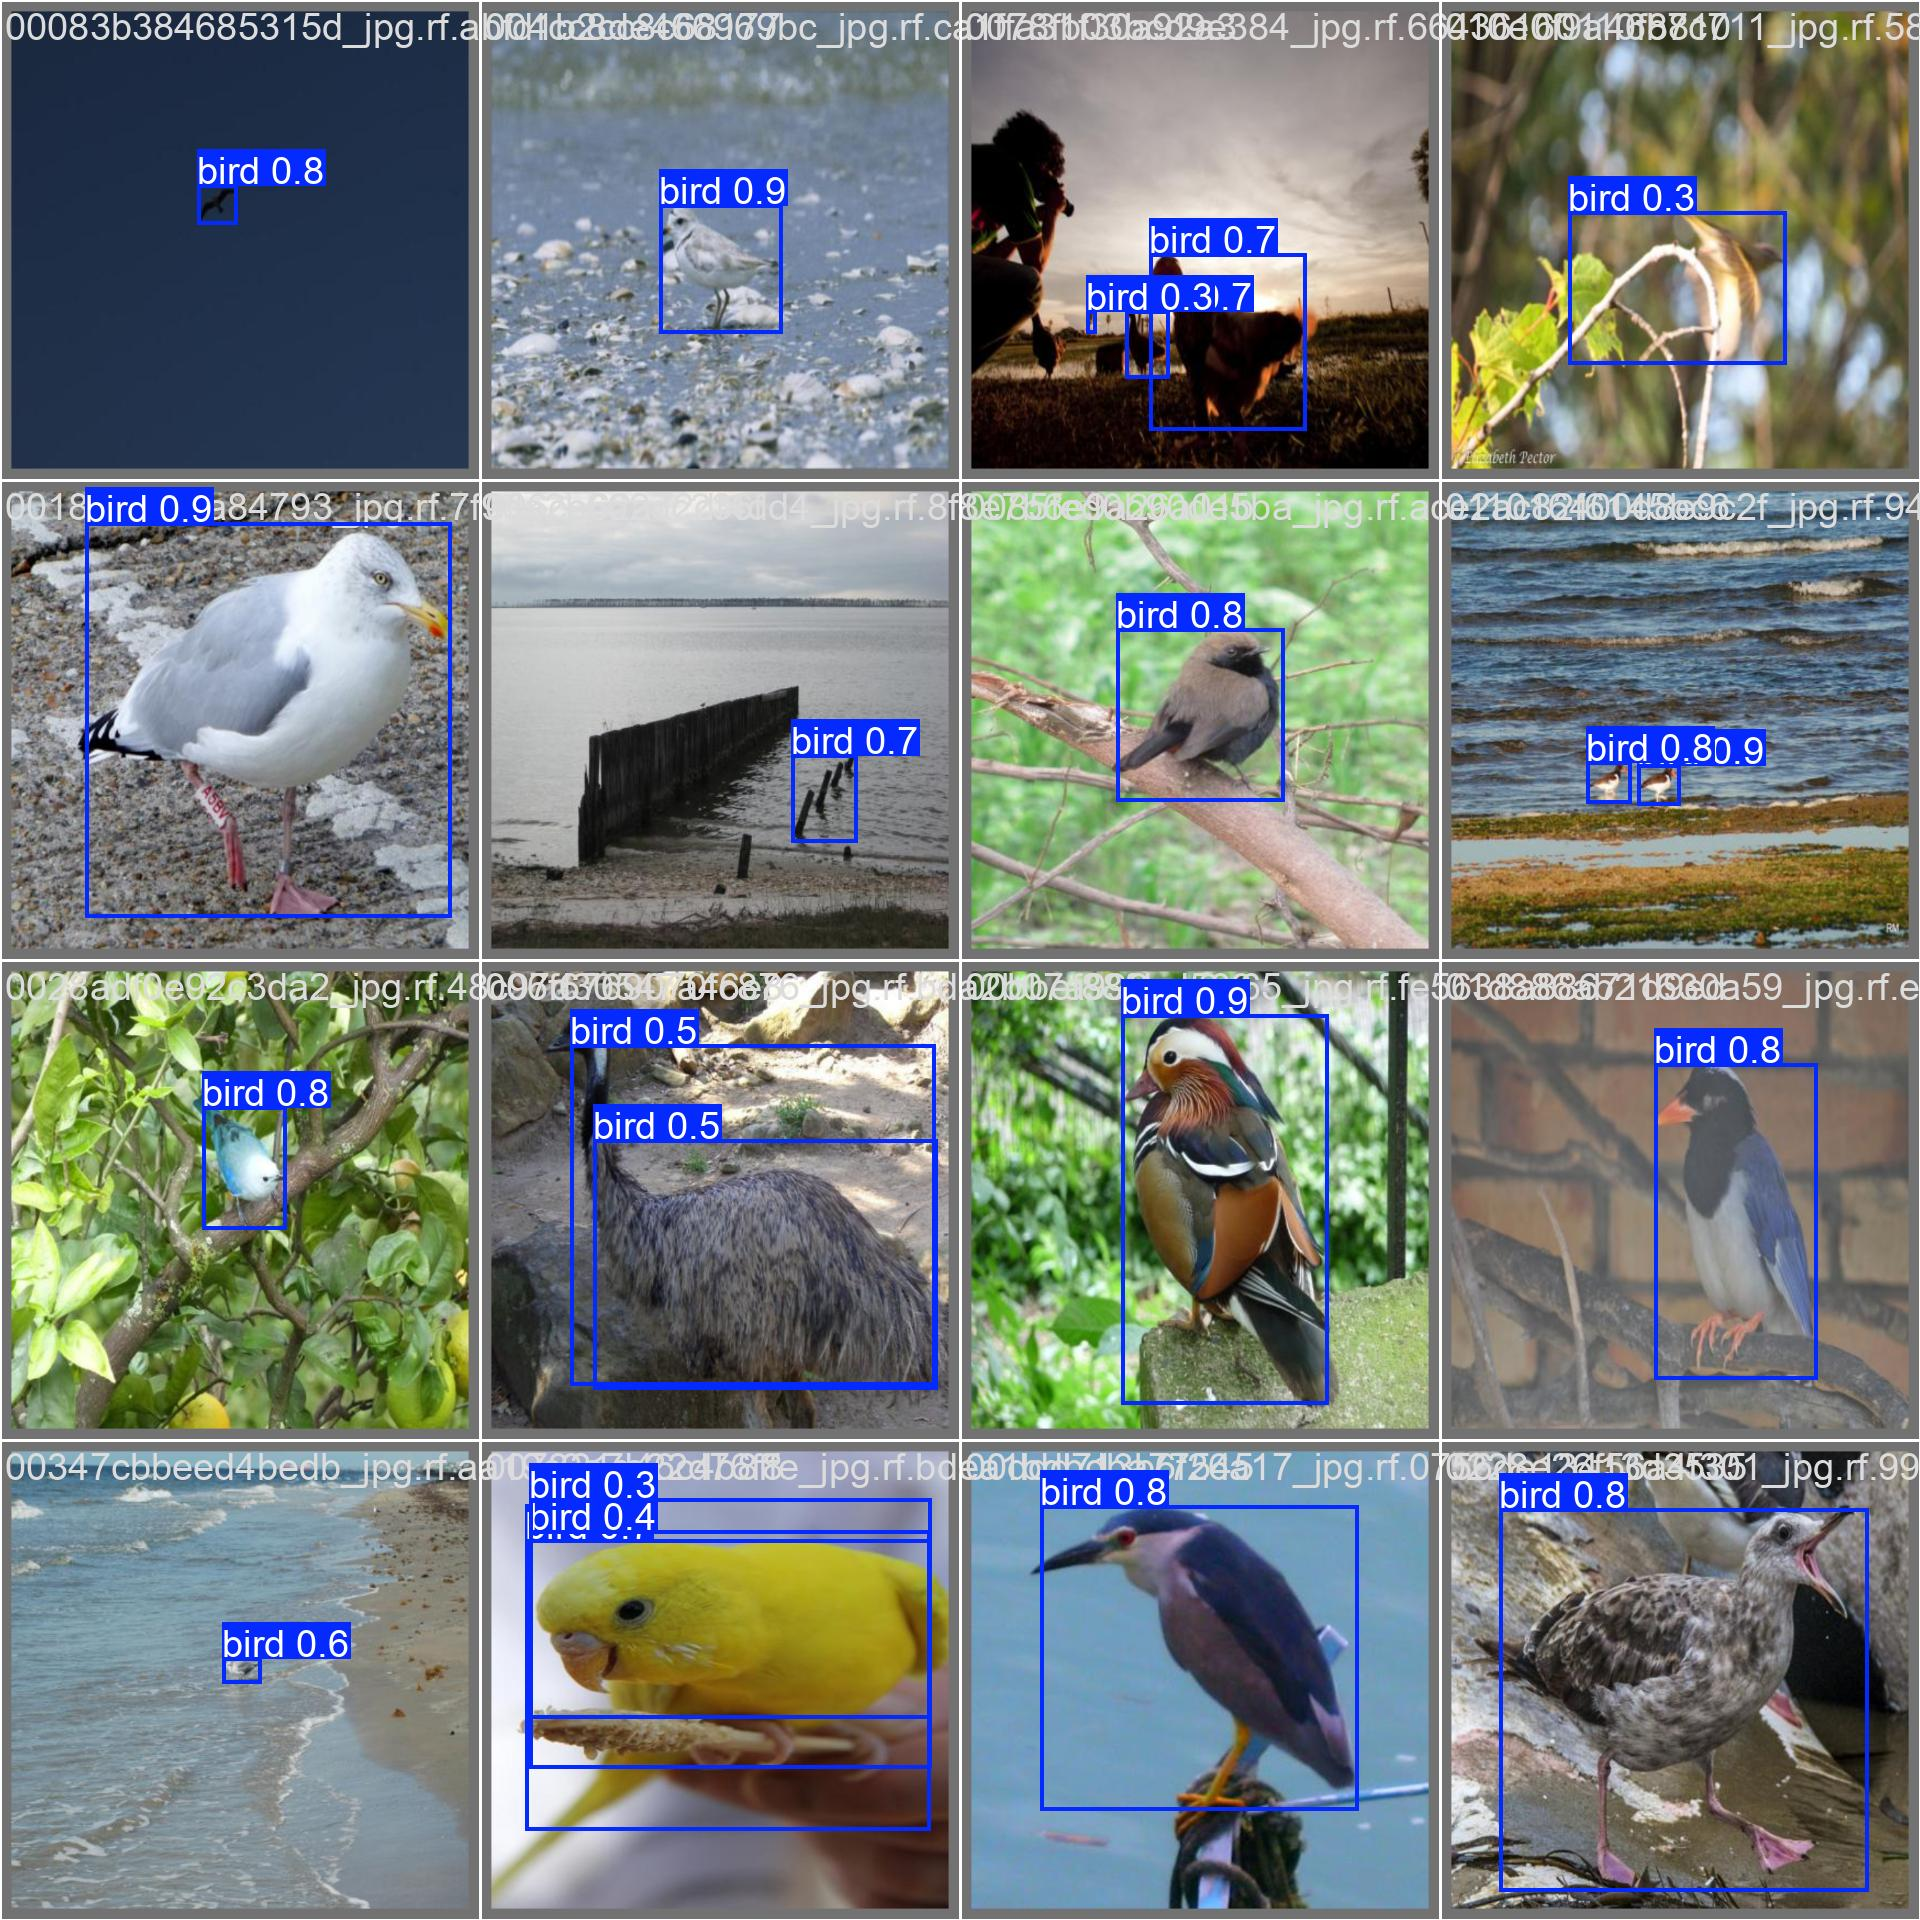

In [12]:
detection_image_path = docs_images_dir / "prediction_sample.png"

if detection_image_path.exists():
    display(Image(filename=str(detection_image_path)))
else:
    print("Detection preview not found.")

## 📊 Performance Summary

### Classification
- Best Model: Automatically selected
- Metrics: Accuracy, Precision, Recall, F1-score

### Detection
- Metrics: mAP, Precision, Recall
- YOLOv8 used for object detection

### Observations
- Transfer learning models outperform custom CNN
- Lightweight models are better for deployment

## 🔍 Key Insights

- Transfer learning significantly improves performance
- Dataset quality directly impacts results
- Some confusion exists between bird and drone due to similar shapes
- YOLOv8 performs well for real-time detection

## ⚠️ Limitations

- Small dataset size
- Limited variation in images
- Model may struggle with:
  - Low resolution images
  - Motion blur
  - Complex backgrounds

## 🔮 Future Improvements

- Increase dataset size
- Add more object classes
- Improve detection accuracy
- Deploy on edge devices
- Real-time video detection

## ✅ Conclusion

This project successfully:
- Built a classification system (Bird vs Drone)
- Implemented object detection using YOLOv8
- Compared multiple models
- Selected the best-performing model
- Prepared the system for deployment

The pipeline is production-ready and can be extended further.